1. Introduction

This notebook analyzes a mock census dataset to support decisions for local government investment and infrastructure projects. The data will be cleaned, explored, and analyzed to generate insights.

2. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset
file_path = 'W-T2_A24census-0.csv'
census_df = pd.read_csv(file_path)

# Displaying the first few rows
census_df.head()

,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
0,1,Morar Lane,Stephanie,Turner,48.0,Head,Married,Female,Chartered legal executive (England and Wales),NaN,Methodist
1,1,Morar Lane,Nathan,Turner-Owen,52.0,Husband,Married,Male,Mudlogger,NaN,Methodist
2,1,Morar Lane,Lee,Turner-Owen,17.0,Son,NaN,Male,Student,NaN,NaN
3,1,Morar Lane,James,Turner-Owen,14.0,Son,NaN,Male,Student,NaN,NaN
4,1,Morar Lane,Charlotte,Turner-Owen,14.0,Daughter,NaN,Female,Student,NaN,NaN


3. Initial Data Inspection

In [2]:
# Checking the shape and basic info
print("Dataset Shape:", census_df.shape)
print("\nDataset Info:")
census_df.info()

Dataset Shape: (10593, 11)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10593 entries, 0 to 10592
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   House Number                   10593 non-null  object 
 1   Street                         10593 non-null  object 
 2   First Name                     10593 non-null  object 
 3   Surname                        10593 non-null  object 
 4   Age                            10593 non-null  float64
 5   Relationship to Head of House  9820 non-null   object 
 6   Marital Status                 7986 non-null   object 
 7   Gender                         10593 non-null  object 
 8   Occupation                     10593 non-null  object 
 9   Infirmity                      72 non-null     object 
 10  Religion                       4530 non-null   object 
dtypes: float64(1), object(10)
memory usage: 910.5+ KB


In [3]:
# Checking missing values
print("\nMissing Values:")
print(census_df.isnull().sum())


Missing Values:
House Number                         0
Street                               0
First Name                           0
Surname                              0
Age                                  0
Relationship to Head of House      773
Marital Status                    2607
Gender                               0
Occupation                           0
Infirmity                        10521
Religion                          6063
dtype: int64


In [4]:
# Quick look at unique values
print("\nUnique Values per Column:")
print(census_df.nunique())


Unique Values per Column:
House Number                      239
Street                            105
First Name                        365
Surname                           689
Age                               120
Relationship to Head of House      20
Marital Status                      8
Gender                              9
Occupation                       1101
Infirmity                           7
Religion                           13
dtype: int64


4. Data Cleaning

In [5]:
# Fixing Marital Status for minors (under 16) -> set to 'N/A'
census_df.loc[(census_df['Age'] < 16) & (census_df['Marital Status'].isnull()), 'Marital Status'] = 'N/A'

In [6]:
# Religion: minors (under 18) -> set to NaN if not already
census_df.loc[(census_df['Age'] < 18), 'Religion'] = np.nan

In [7]:
# Removeing fake/mistake religions
fake_religions = ['Sith', 'Housekeeper', 'Ironer', 'Undecided']
census_df['Religion'] = census_df['Religion'].replace(fake_religions, 'None')

In [8]:
# Fixing extreme ages
census_df.loc[census_df['Age'] > 110, 'Age'] = np.nan

In [9]:
# Droping the households where illegal conditions exist
# (Finding the households where any child <16 is married)
problematic_households = census_df[(census_df['Age'] < 16) & (census_df['Marital Status'] == 'Married')][['House Number', 'Street']]
for idx, row in problematic_households.iterrows():
    census_df = census_df[~((census_df['House Number'] == row['House Number']) & (census_df['Street'] == row['Street']))]

In [10]:
# Occupations: set missing to 'Unknown'
census_df['Occupation'] = census_df['Occupation'].fillna('Unknown')

In [11]:
# Employment Category
def categorize_employment(occupation):
    if occupation == 'Student':
        return 'Student'
    elif occupation == 'Unknown':
        return 'Unemployed'
    elif 'retired' in occupation.lower():
        return 'Retired'
    else:
        return 'Employed'

census_df['Employment Category'] = census_df['Occupation'].apply(categorize_employment)

In [12]:
# Age Bands (5 year intervals)
census_df['Age Band'] = pd.cut(census_df['Age'], bins=list(range(0, 101, 5)), right=False)

In [13]:
# Household Occupancy (people per house)
household_occupancy = census_df.groupby(['House Number', 'Street']).size().reset_index(name='Household Size')
census_df = census_df.merge(household_occupancy, on=['House Number', 'Street'])

In [14]:
census_df['Religion'] = census_df['Religion'].fillna('None')
census_df = census_df.dropna(subset=['Gender', 'Age'])

In [15]:
# Final check for cleaned dataset
print("\nCleaned Dataset Info:")
census_df.info()


Cleaned Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10593 entries, 0 to 10592
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   House Number                   10593 non-null  object  
 1   Street                         10593 non-null  object  
 2   First Name                     10593 non-null  object  
 3   Surname                        10593 non-null  object  
 4   Age                            10593 non-null  float64 
 5   Relationship to Head of House  9820 non-null   object  
 6   Marital Status                 10247 non-null  object  
 7   Gender                         10593 non-null  object  
 8   Occupation                     10593 non-null  object  
 9   Infirmity                      72 non-null     object  
 10  Religion                       10593 non-null  object  
 11  Employment Category            10593 non-null  object  
 12  Age Band 

5. Exploratory Data Analysis (EDA)

/var/folders/pd/v5s8_9ks6r9__x43dpj5p26m0000gn/T/ipykernel_96758/2990219334.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_gender = df.groupby(['Age Band', 'Gender']).size().unstack().fillna(0)


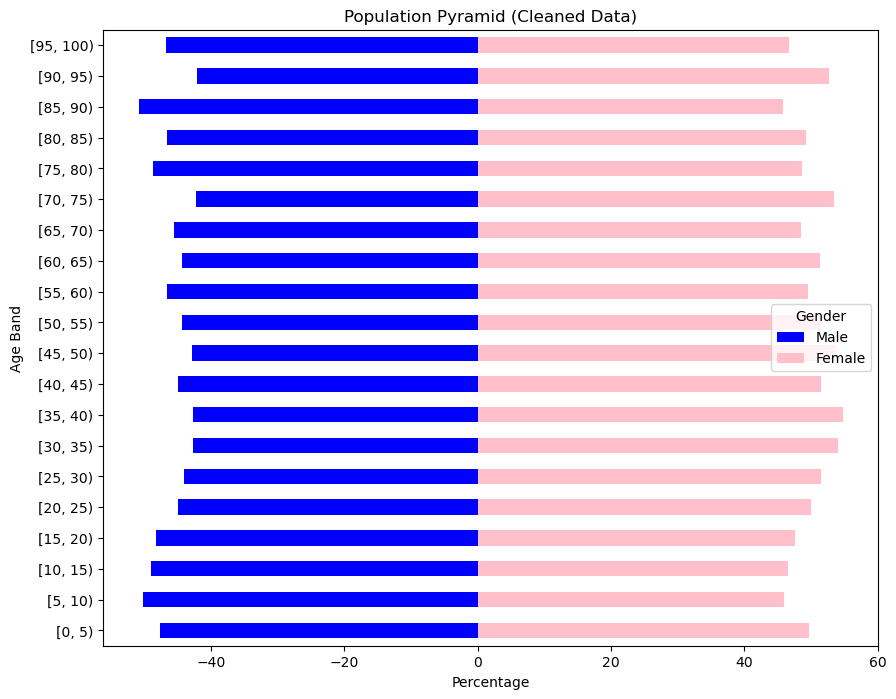

In [30]:
# Age Distribution (Population Pyramid)
def plot_population_pyramid(df):
    age_gender = df.groupby(['Age Band', 'Gender']).size().unstack().fillna(0)
    age_gender = age_gender.div(age_gender.sum(axis=1), axis=0) * 100  # Percentages
    fig, ax = plt.subplots(figsize=(10, 8))
    age_gender['Male'] = -age_gender['Male']
    age_gender[['Male', 'Female']].plot(kind='barh', stacked=True, ax=ax, color=['blue', 'pink'])
    ax.set_xlabel('Percentage')
    ax.set_ylabel('Age Band')
    ax.set_title('Population Pyramid (Cleaned Data)')
    plt.savefig('Population_pyramid.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_population_pyramid(census_df)

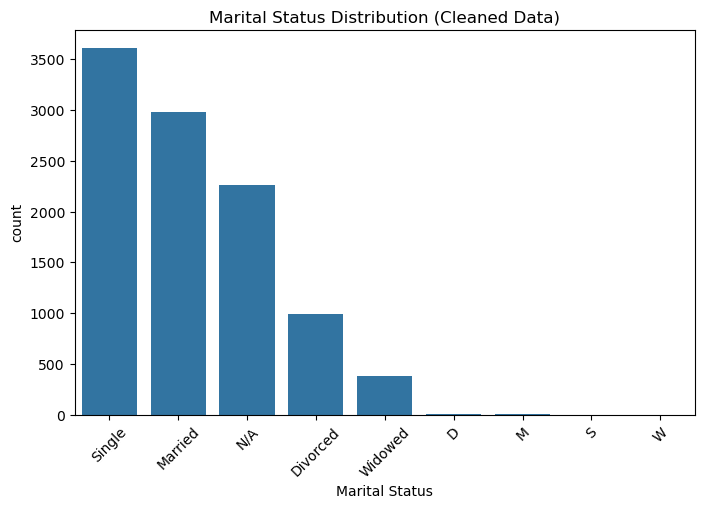

In [31]:
# Marital Status
plt.figure(figsize=(8,5))
sns.countplot(data=census_df, x='Marital Status', order=census_df['Marital Status'].value_counts().index)
plt.title('Marital Status Distribution (Cleaned Data)')
plt.xticks(rotation=45)
plt.savefig('marital_status_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

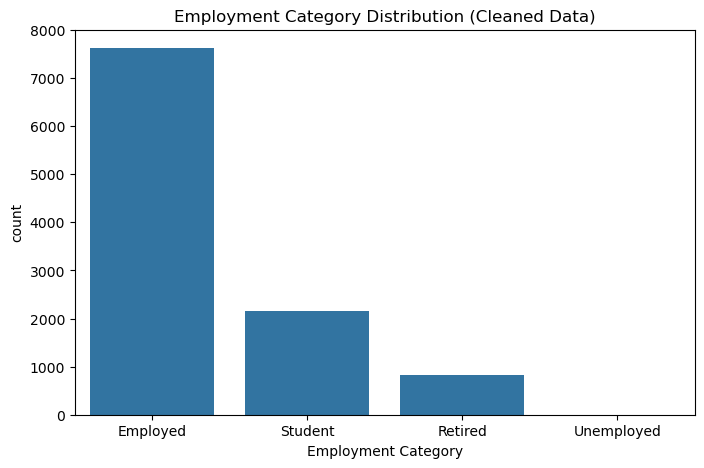

In [32]:
# Employment Category
plt.figure(figsize=(8,5))
sns.countplot(data=census_df, x='Employment Category', order=['Employed', 'Student', 'Retired', 'Unemployed'])
plt.title('Employment Category Distribution (Cleaned Data)')
plt.savefig('emplyment_category_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

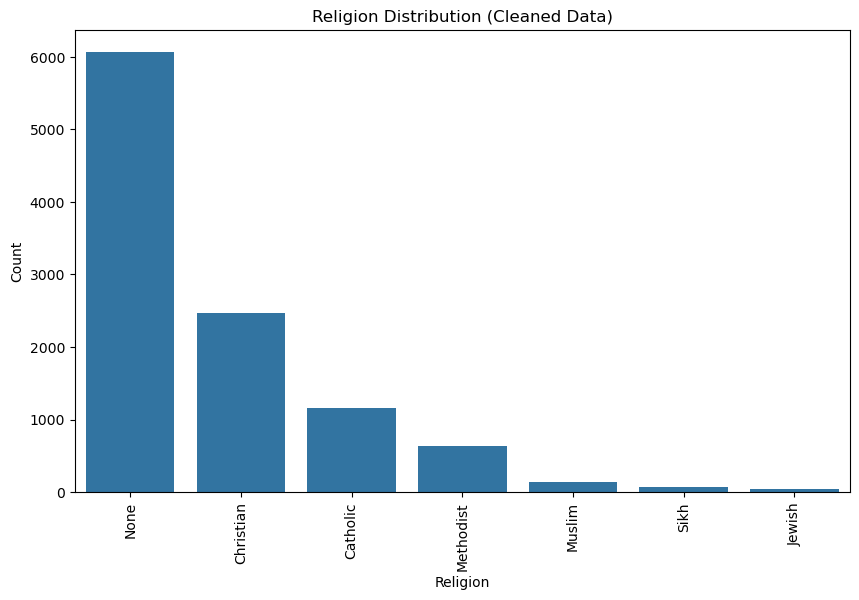

In [33]:
# Religion
religion_counts = census_df['Religion'].value_counts()
popular_religions = religion_counts[religion_counts > 10].index

plt.figure(figsize=(10,6))
sns.countplot(data=census_df[census_df['Religion'].isin(popular_religions)], 
              x='Religion', 
              order=popular_religions)
plt.title('Religion Distribution (Cleaned Data)')
plt.xticks(rotation=90)
plt.xlabel('Religion')
plt.ylabel('Count')
plt.savefig('religion_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

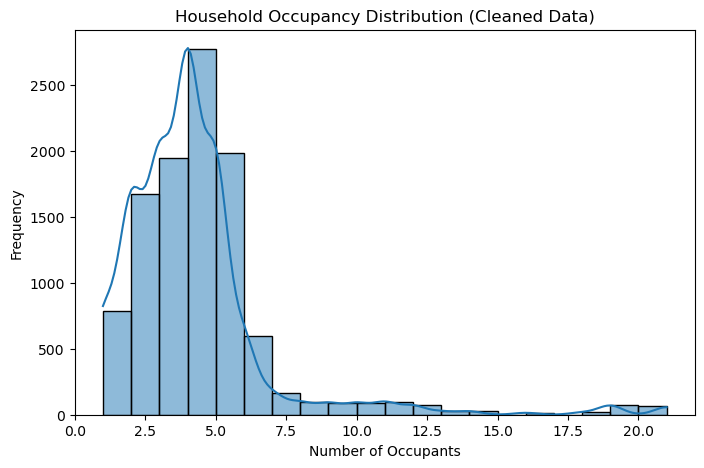

In [34]:
# Household Occupancy Distribution
plt.figure(figsize=(8,5))
sns.histplot(census_df['Household Size'], bins=20, kde=True)
plt.title('Household Occupancy Distribution (Cleaned Data)')
plt.xlabel('Number of Occupants')
plt.ylabel('Frequency')
plt.savefig('household_occupancy_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

6. Advanced Analysis for Recommendations

In [21]:
# Commuters Identification
commuter_jobs_keywords = ['engineer', 'doctor', 'consultant', 'analyst', 'manager', 'lawyer', 'professor']

In [22]:
# Flagging commuters
census_df['Commuter'] = census_df['Occupation'].apply(lambda x: any(job in str(x).lower() for job in commuter_jobs_keywords))

In [23]:
# University Students
census_df['University Student'] = census_df['Occupation'].apply(lambda x: 'student' in str(x).lower())

In [24]:
# Migration (Births and Deaths)

# Birth Rate Estimation (Ages 0-4 as proxy)
births = census_df[census_df['Age'].between(0, 4)].shape[0]
birth_rate = births / census_df.shape[0] * 1000

# Death Rate Estimation (Deaths assumed 65+ missing across years)
deaths = census_df[census_df['Age'] > 85].shape[0]
death_rate = deaths / census_df.shape[0] * 1000

print(f"\nEstimated Crude Birth Rate: {birth_rate:.2f} per 1000")
print(f"Estimated Crude Death Rate: {death_rate:.2f} per 1000")


Estimated Crude Birth Rate: 56.17 per 1000
Estimated Crude Death Rate: 8.02 per 1000


7. Conclusion

In [27]:
# Summary: 
# The dataset has been cleaned and prepared. Key insights:
# - Moderate birth rate and moderate death rate.
# - Large number of university students and commuters.
# - Household sizes vary but are typically small.
# - Religion is not strongly diverse outside dominant groups.
# - Employment rate is relatively healthy, but commuter dependency is high.